# Import Data 

In [47]:
!pip pandas seaborn numpy matplotlib mplsoccer

ERROR: unknown command "pandas"


In [48]:
import pandas as pd
import seaborn as sns

import numpy as np 
import matplotlib.pyplot as plt 
import mplsoccer
home = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Home_Team.csv")
away = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Away_Team.csv")
events = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawEventsData.csv")

/var/folders/lw/fl7prrw1671044k3vst005600000gq/T/ipykernel_24750/1188959503.py:7: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  home = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Home_Team.csv")
/var/folders/lw/fl7prrw1671044k3vst005600000gq/T/ipykernel_24750/1188959503.py:8: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27) have mixed types. Specify dtype option on import or set low_memory=False.
  away = pd.read_csv("/Users/Damian/milon-football/notebook/datasets/game2/Sample_Game_2_RawTrackingData_Away_Team.csv")


# Basic Information of Data Events

In [49]:
print("Number of data",events.shape)

events.describe()

Number of data (1935, 14)


,Period,Start Frame,Start Time [s],End Frame,End Time [s],Start X,Start Y,End X,End Y
count,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1849.000000,1849.000000,1221.000000,1221.000000
mean,1.468217,65422.160207,2616.886408,65444.214470,2617.768579,0.494446,0.518096,0.499476,0.512776
std,0.499118,39412.118805,1576.484752,39410.201977,1576.408079,0.238115,0.297417,0.229955,0.306112
min,1.000000,51.000000,2.040000,51.000000,2.040000,-0.010000,-0.030000,-0.080000,-0.040000
25%,1.000000,30974.500000,1238.980000,30978.000000,1239.120000,0.320000,0.250000,0.340000,0.240000
50%,1.000000,64182.000000,2567.280000,64239.000000,2569.560000,0.500000,0.520000,0.510000,0.520000
75%,2.000000,96722.000000,3868.880000,96756.000000,3870.240000,0.680000,0.790000,0.660000,0.780000
max,2.000000,140265.000000,5610.600000,140298.000000,5611.920000,1.030000,1.020000,1.020000,1.040000


**we have 1935 rows of 14 columns**

we can see that columns such as **Start X,Start Y,End X, End Y** have < 1935 values so we will check if those NaN values are normal


# Missing Value Analysis

In [50]:
print(f"Events Columns: {events.columns}")

Events Columns: Index(['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]',
       'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y',
       'End X', 'End Y'],
      dtype='object')


In [51]:
for col in events.columns:
    print(f"{col} contains: {events[col].isnull().sum()} null values")

Team contains: 0 null values
Type contains: 0 null values
Subtype contains: 1067 null values
Period contains: 0 null values
Start Frame contains: 0 null values
Start Time [s] contains: 0 null values
End Frame contains: 0 null values
End Time [s] contains: 0 null values
From contains: 0 null values
To contains: 971 null values
Start X contains: 86 null values
Start Y contains: 86 null values
End X contains: 714 null values
End Y contains: 714 null values


we are going to do extra analysis on **subtype,to,cordinates** to check if the missing values are due to mistake or because of event actions on football

### Subtype

In [52]:
# check which event types produce those null values
events[events['Subtype'].isnull()]['Type'].value_counts()

Type
PASS              916
RECOVERY           63
BALL OUT           38
BALL LOST          30
FAULT RECEIVED     20
Name: count, dtype: int64

we are going to check on those categories if they have also subtypes but in order to check also the null values we are going to fill them with NONE 

In [53]:
events['Subtype'] = events['Subtype'].fillna("NONE")

In [54]:
passes = events[events['Type']=="PASS"]
recovery = events[events['Type']=='RECOVERY']
ball_out = events[events['Type']=="BALL OUT"]
ball_lost = events[events['Type']=="BALL LOST"]
fault_received = events[events['Type']=="FAULT RECEIVED"]


In [55]:
print("Passes Subtypes")
print(passes['Subtype'].value_counts())
print("######################")
print("Recovery Subtypes")
print(recovery["Subtype"].value_counts())
print("######################")
print("Ball Out Subtype")
print(ball_out['Subtype'].value_counts())

Passes Subtypes
Subtype
NONE                           916
HEAD                            27
GOAL KICK                       12
CROSS                            7
DEEP BALL                        1
HEAD-INTERCEPTION-CLEARANCE      1
Name: count, dtype: int64
######################
Recovery Subtypes
Subtype
INTERCEPTION    145
NONE             63
THEFT            31
SAVED             6
BLOCKED           3
Name: count, dtype: int64
######################
Ball Out Subtype
Subtype
NONE              38
CLEARANCE          5
HEAD               4
HEAD-CLEARANCE     1
CROSS              1
Name: count, dtype: int64


In [56]:
print("Ball Lost Subtype")
print(ball_lost['Subtype'].value_counts())
print("######################")
print("Fault Received Subtype")
print(fault_received['Subtype'].value_counts())

Ball Lost Subtype
Subtype
INTERCEPTION              114
THEFT                      38
NONE                       30
HEAD-INTERCEPTION          15
HEAD                       10
CROSS-INTERCEPTION          8
FORCED                      6
GOAL KICK-INTERCEPTION      4
HAND BALL                   3
CLEARANCE                   2
OFFSIDE                     1
FORCED-END HALF             1
CLEARANCE-INTERCEPTION      1
Name: count, dtype: int64
######################
Fault Received Subtype
Subtype
NONE    20
Name: count, dtype: int64


## Observations

- Most **Pass events** do not contain a subtype (`NONE`), which indicates a normal pass.
- Some passes include additional context such as **HEAD**, **CROSS**, or **GOAL KICK**.
- **Recovery events** are mainly caused by **interceptions**, followed by standard recoveries (`NONE`) and **theft** (tackles).
- **Ball Lost events** mostly occur due to **interceptions** and **theft**, meaning the opposing team regained possession.
- **Ball Out events** are mostly simple ball exits (`NONE`), but sometimes occur after **clearances** or **headers**.
- **Fault Received** events do not include subtype information in this dataset.

Overall, the subtype distribution appears **consistent and logically aligned with football event tagging**, suggesting there are **no major data quality issues** in the `Subtype` column.

### To Column

In [57]:
# we are going to take "problematic rows"
null_to = events[events['To'].isnull()]

In [58]:
null_to.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
6,Away,BALL LOST,INTERCEPTION,1,451,18.04,504,20.16,Player15,NaN,0.26,0.92,0.64,0.93
7,Away,CHALLENGE,GROUND-LOST,1,504,20.16,504,20.16,Player23,NaN,0.61,0.93,NaN,NaN
8,Home,CHALLENGE,GROUND-WON,1,504,20.16,504,20.16,Player3,NaN,0.62,0.92,NaN,NaN
9,Home,RECOVERY,INTERCEPTION,1,504,20.16,504,20.16,Player3,NaN,0.62,0.92,NaN,NaN


**we will check the event types**

In [59]:
null_to["Type"].value_counts()

Type
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: count, dtype: int64

### Events where To should be normally Null

- Recovery -> player regains position
- Ball Lost -> player losses possession
- Ball Out -> ball leaves field
- Shot -> player shoots
- Set Piece -> restart action
- Fault Received -> player who suffere the foul
- Card -> referee give a card to a player (we say player received a card)

for the challenge event due to the dataset being a certain way including both home and away we will check if both teams appear for the same moment , to confirm it

In [60]:
events[events['Type']=='CHALLENGE'][['Team','From',"Subtype"]]

,Team,From,Subtype
7,Away,Player23,GROUND-LOST
8,Home,Player3,GROUND-WON
18,Home,Player6,AERIAL-WON
21,Away,Player23,AERIAL-LOST
30,Away,Player18,AERIAL-LOST
...,...,...,...
1919,Home,Player1,GROUND-FAULT-WON
1923,Away,Player17,AERIAL-FAULT-LOST
1924,Home,Player7,AERIAL-FAULT-WON
1931,Home,Player1,AERIAL-LOST


that confirms it so we don't have a problem regarding with To column for the **CHALLENGE** Type being null

# Coordinates Columns
first verify symmetry

In [61]:
(events['Start X'].isnull() != events['Start Y'].isnull()).sum()

0

the same for the end coordinates

In [62]:
(events['End X'].isnull() != events['End Y'].isnull()).sum()

0

**check which events causing Start Coordinates**

In [63]:
start_null = events[events['Start X'].isnull()]
start_null["Type"].value_counts()

Type
SET PIECE    80
CARD          6
Name: count, dtype: int64

completely normal 
- Card -> referee decision
- Set Piece -> doesn't so clear spatial origin

In [64]:
# same for end coordinates
end_null = events[events['End X'].isnull()]
end_null['Type'].value_counts()

Type
CHALLENGE         311
RECOVERY          248
SET PIECE          80
BALL LOST          48
FAULT RECEIVED     20
CARD                6
BALL OUT            1
Name: count, dtype: int64

#### Events Causing Missing `End X` / `End Y` Coordinates

| Event Type | Count | Why End Coordinates Are Missing |
|---|---|---|
| CHALLENGE | 311 | Duel between players; the ball may not move spatially. |
| RECOVERY | 248 | A player regains possession at a specific location; no ball trajectory is recorded. |
| SET PIECE | 80 | Marks a restart event (e.g., corner, free kick) rather than a ball movement. |
| BALL LOST | 48 | Possession ends, but the ball trajectory after the loss is not tracked. |
| FAULT RECEIVED | 20 | Foul event involving a player; it does not describe ball movement. |
| CARD | 6 | Administrative referee decision event; no spatial ball movement involved. |
| BALL OUT | 1 | The ball leaves the field; the event records the location where it occurred. |

**so the end coordinates are okay**

## Event Distribution

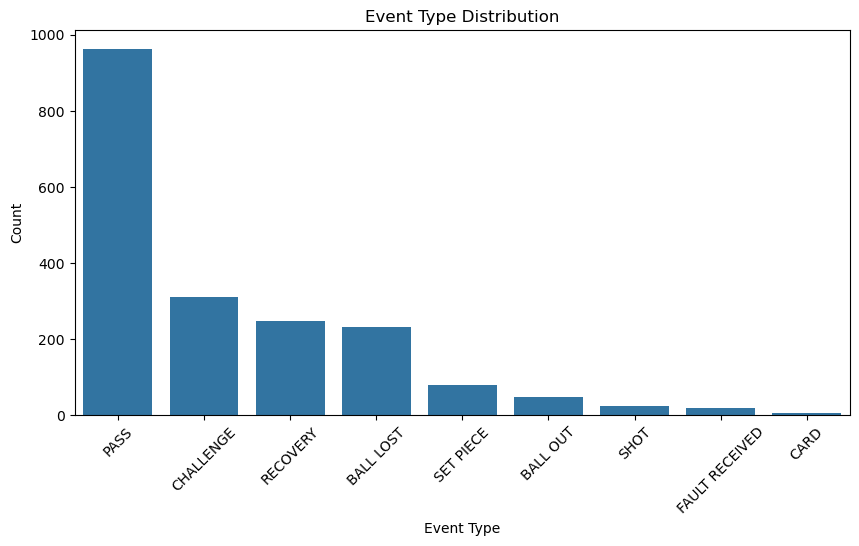

In [65]:
event_distribution = events['Type'].value_counts()
plt.figure(figsize=(10,5))

sns.barplot(
    x=event_distribution.index,
    y = event_distribution.values
)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

from the plot we can see that the game had a lot of:
- possesion
- duels (challenges) aggresive game
- frequency on losing and recovering the ball

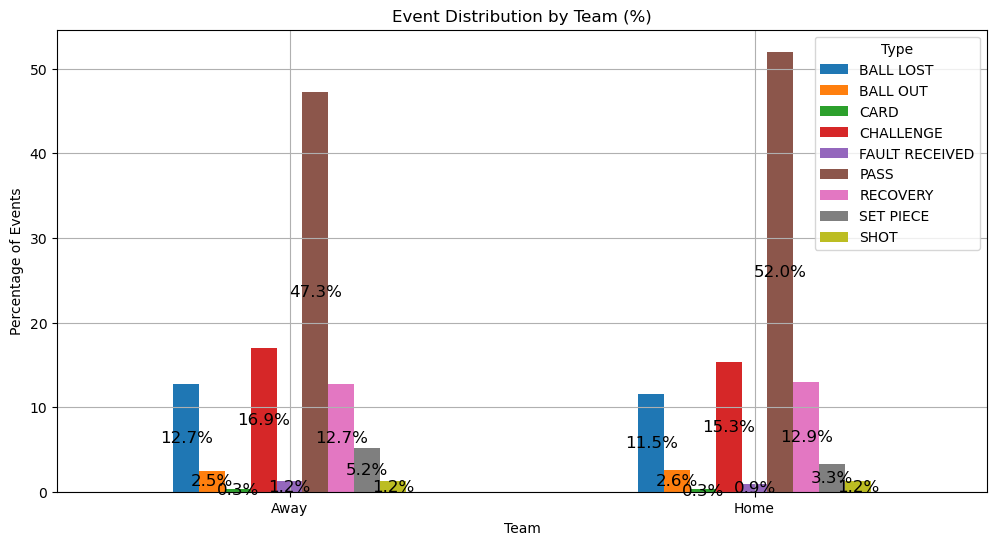

In [66]:

# count events
team_events = events.groupby(['Team','Type']).size().unstack(fill_value=0)

# convert counts → percentages per team
team_events_pct = team_events.div(team_events.sum(axis=1), axis=0) * 100

ax = team_events_pct.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Event Distribution by Team (%)")
plt.xlabel("Team")
plt.ylabel("Percentage of Events")
plt.xticks(rotation=0)
plt.grid(True)

# add percentage labels
for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=12)

plt.show()

### Event Distribution by Team

The percentage distribution of event types is relatively balanced between the Home and Away teams. Most event categories appear with similar proportions for both teams, suggesting that the match dynamics and types of actions performed were broadly comparable.

Nevertheless, some event types show moderate differences in frequency between the teams. These variations may reflect tactical differences, such as higher defensive pressure, more recoveries, or increased attacking actions by one team.

# Per Period

<Figure size 1000x500 with 0 Axes>

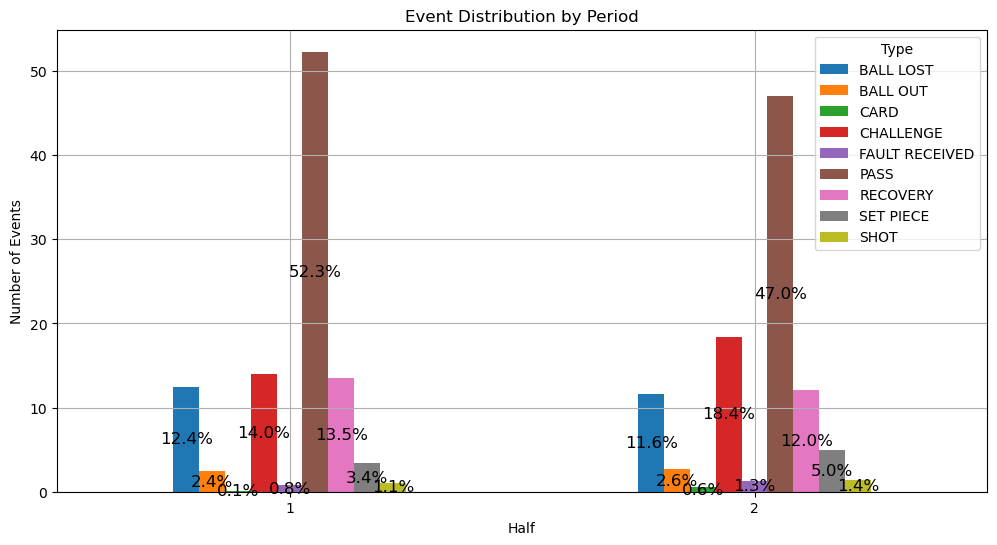

In [67]:
plt.figure(figsize=(10,5))

period_events = events.groupby(["Period","Type"]).size().unstack(fill_value=0)

period_events_pct = period_events.div(period_events.sum(axis=1),axis=0)*100


ax = period_events_pct.plot(
    kind='bar',
    stacked=False,
    figsize=(12,6) 
)

plt.title("Event Distribution by Period")
plt.xlabel("Half")
plt.ylabel("Number of Events")
plt.grid(True)
plt.xticks(rotation=0)

for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=12)
plt.show()


# SubTypes Distribution 

In [68]:
def plot_subtype_distribution(df,type_col="Type",subtype_col='Subtype',show_pct=True):
    event_types = df[type_col].unique()

    for event in event_types:
        subset = df[df[type_col]==event]
        counts = subset[subtype_col].value_counts()

        if show_pct:
            counts = counts/counts.sum()*100
        plt.figure(figsize=(8,4))
        sns.barplot(
            x=counts.index,
            y=counts.values
        )

        plt.title(f"{event} Subtype Distribution")
        plt.xlabel("Subtype")
        plt.ylabel("Percentage % " if show_pct else "Count")
        plt.xticks(rotation=90)
        plt.grid(True)

        plt.show()

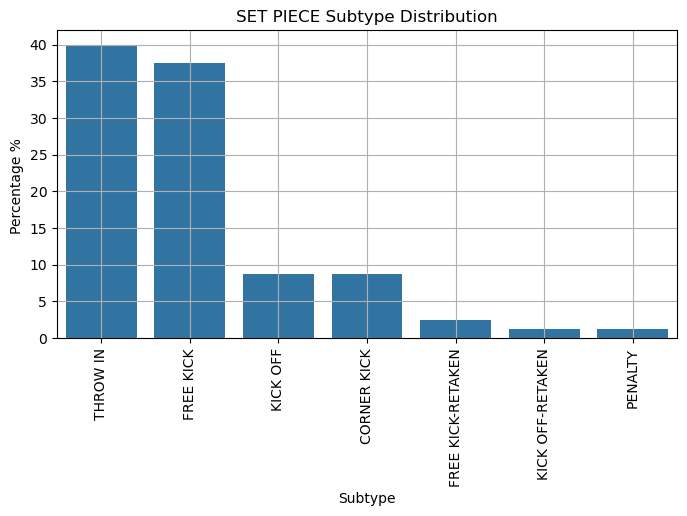

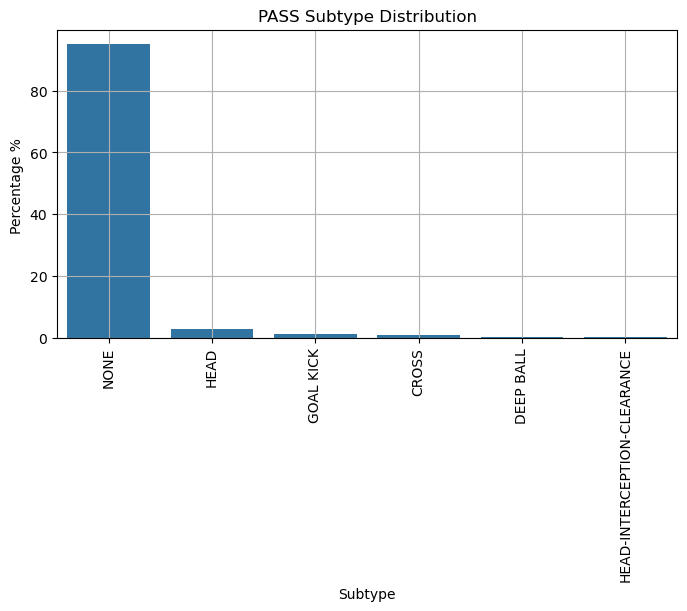

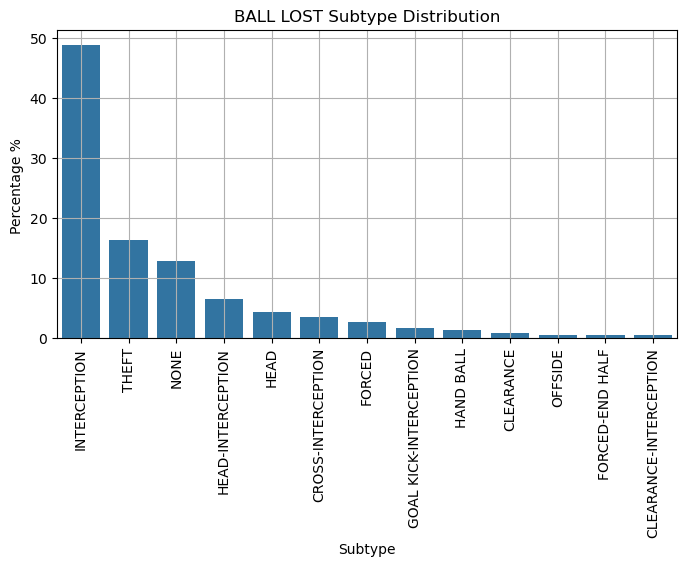

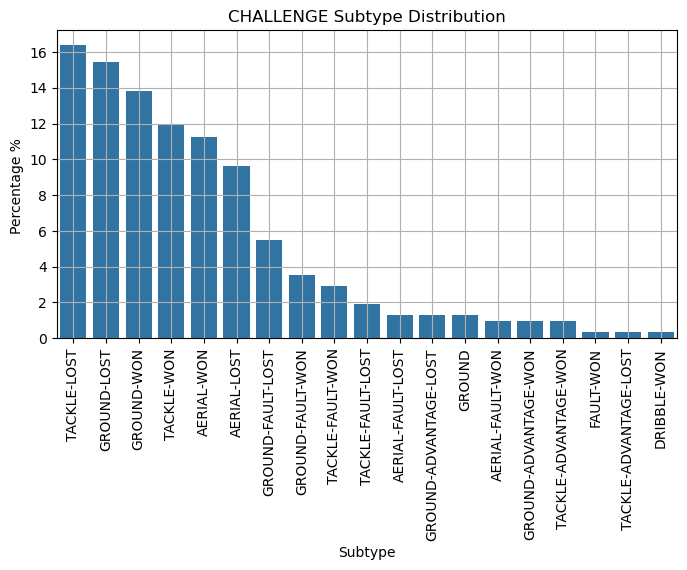

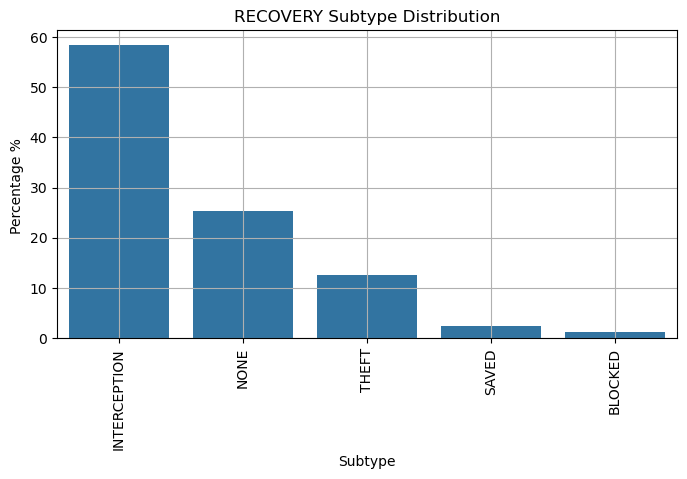

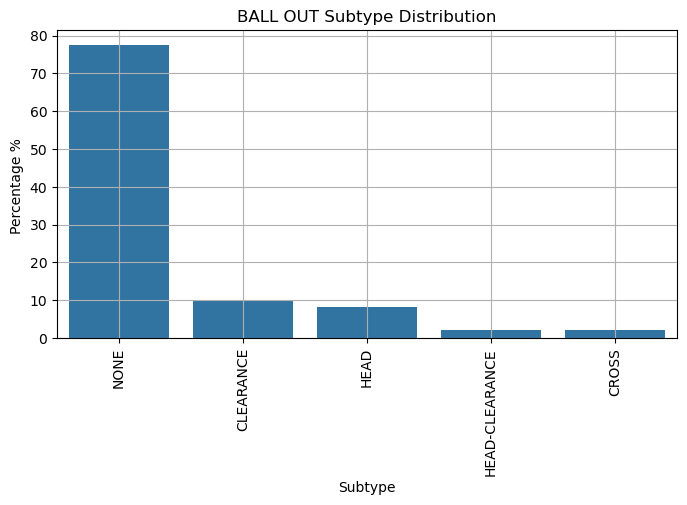

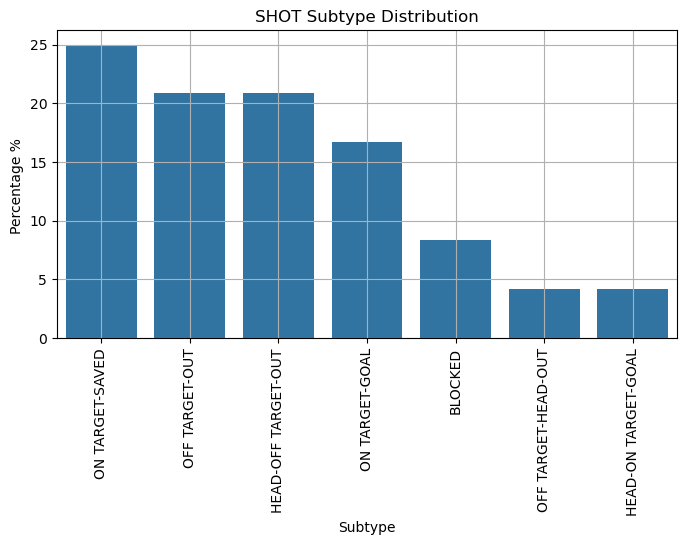

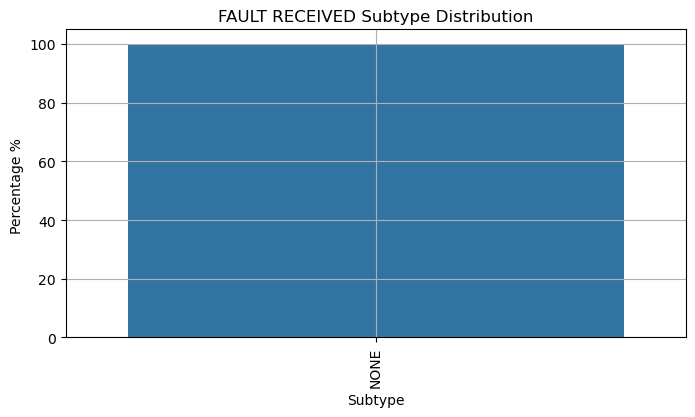

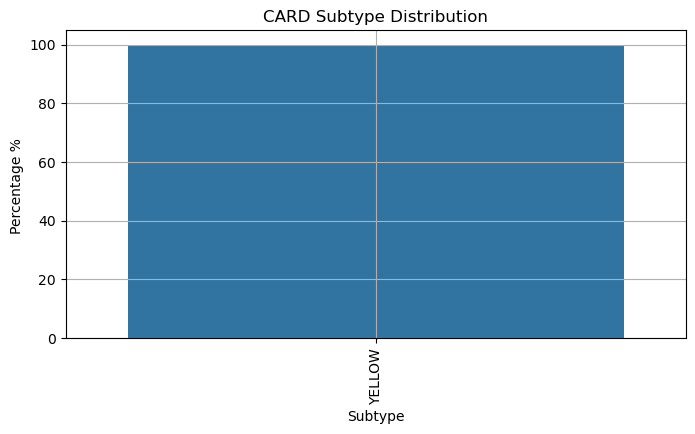

In [69]:
plot_subtype_distribution(events)

## Game Analysis

### Statistics Per team
important statistics for one match are:
- shots
- shots on Target
- goals
- passes
- possession
- tackles
- yellow cards
- red cards
- interceptions
- tackles 

We do it in order to see which team was the most dominate team in the game and in which sector

**attacking stats**

In [70]:
def get_shots(df:pd.DataFrame) -> pd.Series:
    # total shots attempted by each team
    shots = df[df['Type']=="SHOT"]
    return (shots.groupby("Team").size()
            .reindex(["Home","Away"]).fillna(0).astype(int))

def get_shots_on_target(df:pd.DataFrame)->pd.Series:
    shots = df[df["Type"]=="SHOT"]
    sot = shots[shots["Subtype"].str.contains("ON TARGET")]
    return (sot.groupby("Team").size()
            .reindex(["Home","Away"]).fillna(0).astype(int))

def get_goals(df:pd.DataFrame)-> pd.Series:
    shots= df[df['Type']=="SHOT"]
    goals = shots[shots['Subtype'].str.contains('GOAL')]
    return (goals.groupby("Team").size()
            .reindex(["Home","Away"]).fillna(0).astype(int))

**xGoals**
xG assigns every shot a probability (0-1) in a goal based on how difficult th chances was, purely from geometry:
- Distance to goal (metres)
- shot angle  

A logistic regression style convers those to two features into a probability

In [71]:
# ── FIFA pitch constants (metres) ─────────────────────────────────────────────
W, H        = 105.0, 68.0
PA_D, PA_W  = 16.5,  40.32
SB_D, SB_W  = 5.5,   18.32
PEN_DIST    = 11.0
CR          = 9.15
GOAL_W      = 7.32
GOAL_D      = 2.0
LEFT_GOAL   = (0.0, H / 2)
RIGHT_GOAL  = (W,   H / 2)

In [72]:
def _to_m(x, y):
    """Scale normalised [0-1] coords to FIFA metres (105×68)."""
    return np.asarray(x, dtype=float) * W, np.asarray(y, dtype=float) * H

def attacking_goal(team: str, period: int) -> tuple:
    """
    Goal the team is attacking.
    P1: Home → left (x=0), Away → right (x=105)
    P2: Home → right (x=105), Away → left (x=0)
    """
    if (team == "Home" and period == 1) or (team == "Away" and period == 2):
        return LEFT_GOAL
    return RIGHT_GOAL

In [73]:
def sigmoid(z): return 1.0/(1.0+np.exp(-z))

def compute_xg(shot_x_m,shot_y_m,goal_x_m,goal_y_m):
    distance = np.sqrt((shot_x_m-goal_x_m)**2  + (shot_y_m-goal_y_m)**2)
    depth = abs(shot_x_m-goal_x_m)+1e-6
    angle = 2* np.arctan((GOAL_W/2)/depth)
    z = -0.012+0.096*angle - 0.067*distance
    return float(sigmoid(z))

def add_xg_to_shots(df):
    shots = df[df['Type']=='SHOT'].copy().dropna(subset=['Start X','Start Y'])
    xg_values = []
    for _, row in shots.iterrows():
        xm, ym = _to_m(row["Start X"], row["Start Y"])
        gx, gy = attacking_goal(row["Team"], row["Period"])
        xg_values.append(compute_xg(float(xm), float(ym), gx, gy))
    shots["xg"] = xg_values
    return shots

def _get_total_xg(df)-> pd.Series: 
    shots = add_xg_to_shots(df)
    return (shots.groupby('Team')['xg']
            .sum()
            .reindex(['Home','Away'])
            .fillna(0)
            .round(2))

**passing stats**

In [74]:
def get_passes(df:pd.DataFrame)->pd.Series:
    # total passes per team
    passes = df[df['Type']=='PASS']
    return (passes.groupby("Team").size()
            .reindex(["Home","Away"]).fillna(0).astype(int))

def get_pass_accuracy(df:pd.DataFrame) -> pd.Series:
    # pass accuracy as percentage
    total = get_passes(df)
    lost = (df[(df['Type']== 'BALL LOST') & (df['Subtype'].str.contains('INTERCEPTION|HEAD'))]
            .groupby('Team').size()
            .reindex(['Home','Away']).fillna(0))
    
    completed = (total-lost).clip(lower=0)
    return (completed / total*100).round(2)

def get_possession(df:pd.DataFrame) -> pd.Series:
    # estimated ball possession 
    passes = get_passes(df)
    return (passes/passes.sum()*100).round(1)

**Defensive Stats**

In [75]:
def get_tackles(df:pd.DataFrame)->pd.Series:
    # total tackle attempts
    challenges = df[df["Type"]=="CHALLENGE"]
    tackles = challenges[challenges['Subtype'].str.contains('TACKLE')]
    
    return (tackles.groupby("Team").size()
            .reindex(['Home','Away']).fillna(0).astype(int))

def get_fouls(df:pd.DataFrame) -> pd.Series:
    # fouls commited per team
    """
    In the dataset FAULT RECEIVED event is logged against the team that was fouled
    So we change it to put it to the team that committed the foul
    """
    received = (df[df['Type']=="FAULT RECEIVED"]
                .groupby("Team").size()
                .reindex(['Home','Away']).fillna(0).astype(int))
    
    fouls = received.rename(index={"Home":"Away","Away":"Home"})
    return fouls.reindex(['Home','Away'])

def get_interceptions(df: pd.DataFrame)->pd.Series:
    # interception -> represent moment a player actively won the ball from opponent
    interceptions = df[
        (df['Type']=='RECOVERY') &
        (df['Subtype'].str.contains('INTERCEPTION'))
    ]
    return (interceptions.groupby("Team").size()
            .reindex(['Home','Away']).fillna(0).astype(int))

**Disciplinary Stats**


In [76]:
def get_yellow_cards(df:pd.DataFrame)-> pd.Series:
    yellows = df[(df['Type']=='CARD') & (df['Subtype']=='YELLOW')]
    return (yellows.groupby('Team').size()
            .reindex(['Home','Away']).fillna(0).astype(int))

def get_red_cards(df:pd.DataFrame)-> pd.Series:
    reds = df[(df['Type']=='CARD') & (df['Subtype']=='RED')]
    return (reds.groupby('Team').size()
            .reindex(['Home','Away']).fillna(0).astype(int))

**Set Pieces**

In [77]:
def get_corners(df:pd.DataFrame)-> pd.Series:
    # corner kicks awared per team
    corners = df[
        (df["Type"]=="SET PIECE") &
        (df['Subtype'] == "CORNER KICK")
    ]
    return (corners.groupby('Team').size()
            .reindex(['Home','Away']).fillna(0).astype(int))

In [78]:
stats = {
        "Goals":             get_goals(events),
        "Shots":             get_shots(events),
        "Shots on Target":   get_shots_on_target(events),
        "Passes":            get_passes(events),
        "Possession (%)":    get_possession(events),
        "Pass Accuracy (%)": get_pass_accuracy(events),
        "Tackles":           get_tackles(events),
        "Fouls":             get_fouls(events),
        "Interceptions":     get_interceptions(events),
        "Yellow Cards":      get_yellow_cards(events),
        "Red Cards":         get_red_cards(events),
        "Corners":           get_corners(events),
}
names = True
for name , series in stats.items():
    h = series['Home']
    a = series['Away']
    fh = f"{h:.1f}" if isinstance(h, float) else str(h)
    fa = f"{a:.1f}" if isinstance(a, float) else str(a)
    if names:
        print(f"                               Home      Away")
        names= False
    print(f"  {name:<23} {fh:>6}  {fa:>6}")


                               Home      Away
  Goals                        3       2
  Shots                       13      11
  Shots on Target              7       4
  Passes                     543     421
  Possession (%)            56.3    43.7
  Pass Accuracy (%)         84.7    83.6
  Tackles                     41      66
  Fouls                       11       9
  Interceptions               74      71
  Yellow Cards                 3       3
  Red Cards                    0       0
  Corners                      4       3


### Stats visualization

In [79]:
# values that will be used for the visualisation
HOME_COLOR  = "#1A73E8"
AWAY_COLOR  = "#E84C1A"
BG_COLOR    = "#0D1117"
PANEL_COLOR = "#161B22"
TEXT_COLOR  = "#E6EDF3"
GRID_COLOR  = "#30363D"
 
# StatsBomb pitch dimensions (mplsoccer default)
SB_X, SB_Y = 120.0, 80.0

**Shot Map Visualizations**

In [80]:
from mplsoccer import Pitch
import matplotlib.patheffects as pe
def _to_sb(x,y):
    # convert normalised [0,1] CSV coords -> StatsBomb (120*80)
    return np.asarray(x,float)*SB_X, np.asarray(y,float)*SB_Y

def plot_shot_map(df:pd.DataFrame,save_path:str = None)-> None:
    shots = df[df['Type']=='SHOT'].copy().dropna(
        subset=['Start X','Start Y']
    )
    shots['is_goal'] = shots['Subtype'].str.contains('GOAL')
    shots['on_tgt'] = shots['Subtype'].str.contains("ON TARGET")

    #pitch
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#1a472a",       # deep grass green
        line_color="#ffffff",
        stripe=True,
        stripe_color="#1e5230",      # alternating stripe shade
        line_zorder=2,
    )
 
    fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(18, 8))
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(
        "Shot Map", fontsize=17, fontweight="bold", color=TEXT_COLOR, y=1.02
    )
    # ── one panel per team ────────────────────────────────────────────
    for team, color, ax in [
        ("Home", HOME_COLOR, axes[0]),
        ("Away", AWAY_COLOR, axes[1]),
    ]:
        ts      = shots[shots["Team"] == team]
        blocked = ts[~ts["on_tgt"] & ~ts["is_goal"]]
        on_tgt  = ts[ts["on_tgt"]  & ~ts["is_goal"]]
        goals   = ts[ts["is_goal"]]
 
        # convert coordinates to StatsBomb space
        bx, by = _to_sb(blocked["Start X"], blocked["Start Y"])
        ox, oy = _to_sb(on_tgt["Start X"],  on_tgt["Start Y"])
        gx, gy = _to_sb(goals["Start X"],   goals["Start Y"])
 
        # off target / blocked  — team-coloured filled circle
        pitch.scatter(
            bx, by, ax=ax,
            s=80, color=color, edgecolors="white",
            linewidth=0.8, marker="o", alpha=0.75,
            zorder=4, label="Off / Blocked",
        )
 
        # on target (saved)  — white circle with team-colour edge
        pitch.scatter(
            ox, oy, ax=ax,
            s=130, color="white", edgecolors=color,
            linewidth=1.5, marker="o", alpha=0.90,
            zorder=5, label="On Target",
        )
 
        # goals  — gold star, largest marker
        pitch.scatter(
            gx, gy, ax=ax,
            s=260, color="gold", edgecolors="white",
            linewidth=1.2, marker="*", alpha=1.0,
            zorder=6, label="Goal",
        )
 
        # annotate each goal with a 'GOAL' text label
        for _, row in goals.iterrows():
            mx, my = _to_sb(row["Start X"], row["Start Y"])
            ax.text(
                float(mx) + 1.5, float(my) + 1.5, "GOAL",
                fontsize=7, color="gold", fontweight="bold", zorder=8,
                path_effects=[pe.withStroke(linewidth=2, foreground="black")],
            )
 
        # panel title
        n_s   = len(ts)
        n_g   = len(goals)
        n_sot = len(on_tgt) + n_g
        ax.set_title(
            f"{team}  |  Shots: {n_s}   On Target: {n_sot}   Goals: {n_g}",
            fontsize=12, fontweight="bold", color=color, pad=10,
        )
        ax.legend(
            loc="upper right", framealpha=0.25, fontsize=9,
            labelcolor=TEXT_COLOR, facecolor=PANEL_COLOR, edgecolor=GRID_COLOR,
        )
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()


Saved → img/Shot_Map.png


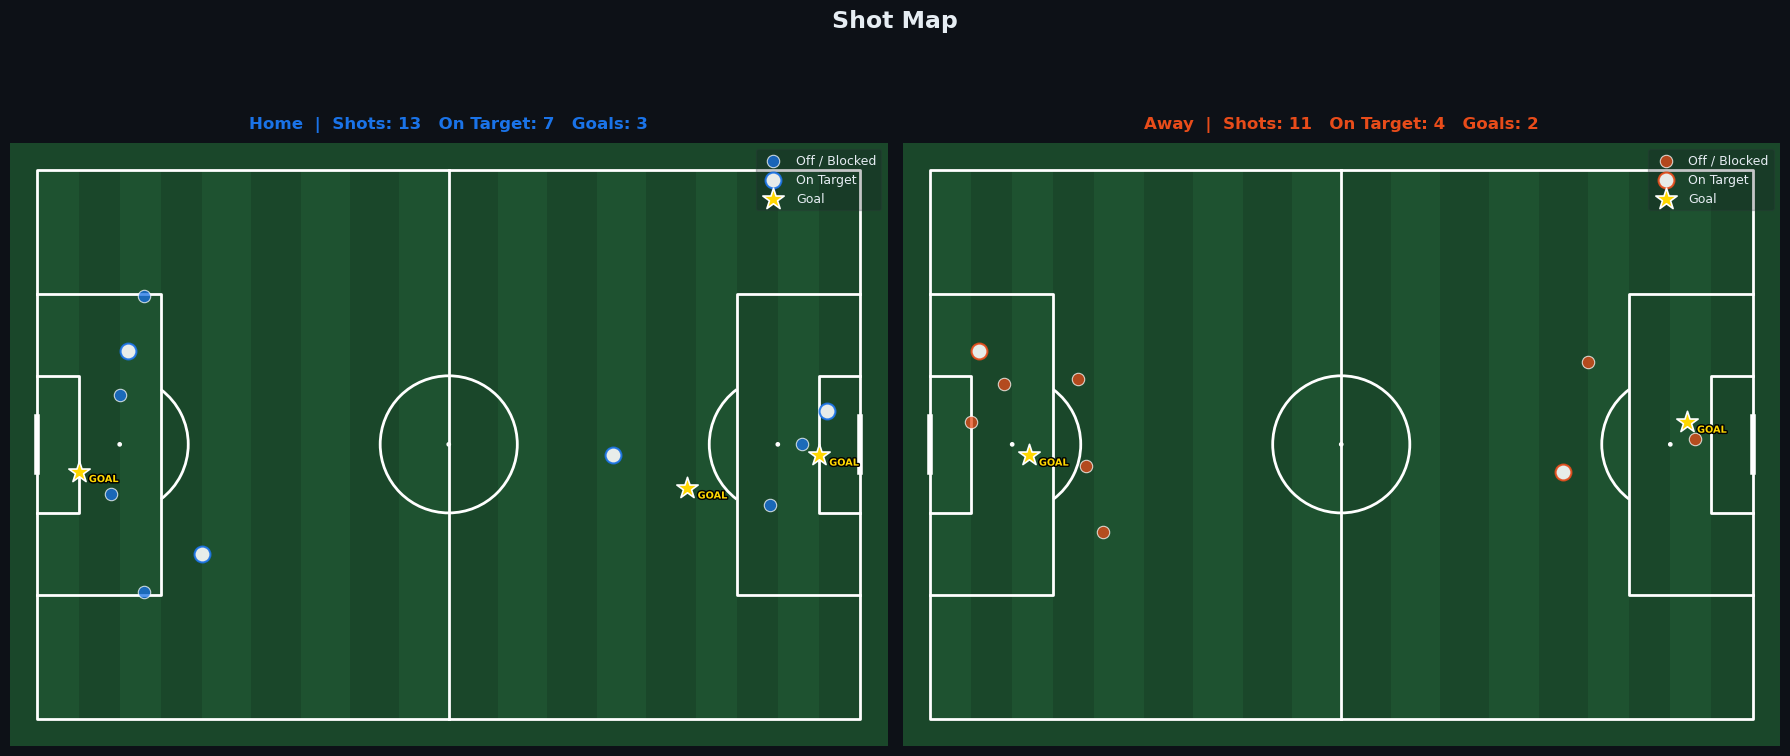

In [81]:
plot_shot_map(events,save_path="img/Shot_Map.png")

**Pass Network**

In [82]:
TOP_N=100
def plot_pass_network(df:pd.DataFrame,top_n:int=TOP_N,save_path:str=None)->None:
    passes = df[df['Type']=="PASS"].dropna(
        subset=['From','To','Start X','Start Y']
    )

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#1a472a",
        line_color="#ffffff",
        stripe=True,
        stripe_color="#1e5230",
        line_zorder=2,
    )
 
    fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(18, 8))
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(
        f"Pass Network (top {top_n} connections per team)",
        fontsize=17, fontweight="bold", color=TEXT_COLOR, y=1.02,
    )

    # ── one panel per team ────────────────────────────────────────────
    for team, color, ax in [
        ("Home", HOME_COLOR, axes[0]),
        ("Away", AWAY_COLOR, axes[1]),
    ]:
        t = passes[passes["Team"] == team]
 
        # 1. average starting position per player → their "home zone"
        avg_pos = (
            t.groupby("From")[["Start X", "Start Y"]]
            .mean()
            .rename(columns={"Start X": "x", "Start Y": "y"})
        )
 
        # 2. count passes between each (From → To) pair
        combos = (
            t.groupby(["From", "To"]).size()
            .reset_index(name="cnt")
            .sort_values("cnt", ascending=False)
            .head(top_n)
        )
        max_cnt = combos["cnt"].max()
 
        # 3. draw edges with pitch.lines()
        for _, row in combos.iterrows():
            if row["From"] not in avg_pos.index or row["To"] not in avg_pos.index:
                continue
 
            x0, y0 = _to_sb(avg_pos.loc[row["From"], "x"],
                             avg_pos.loc[row["From"], "y"])
            x1, y1 = _to_sb(avg_pos.loc[row["To"],   "x"],
                             avg_pos.loc[row["To"],   "y"])
 
            # thicker line = more passes; more opaque = more passes
            lw    = 1.5 + 5.5 * row["cnt"] / max_cnt
            alpha = 0.35 + 0.55 * row["cnt"] / max_cnt
 
            # pitch.lines() is mplsoccer's method for drawing pitch lines;
            # it handles coordinate orientation automatically
            pitch.lines(
                float(x0), float(y0),
                float(x1), float(y1),
                ax=ax,
                lw=lw, color=color, alpha=alpha,
                zorder=3, comet=False,
            )
 
            # pass-count label at edge midpoint
            mx = (float(x0) + float(x1)) / 2
            my = (float(y0) + float(y1)) / 2
            ax.text(
                mx, my, str(int(row["cnt"])),
                fontsize=6.5, color="white", ha="center", va="center",
                fontweight="bold", zorder=6,
                path_effects=[pe.withStroke(linewidth=2, foreground="black")],
            )
 
        # 4. draw player nodes with pitch.scatter()
        n_passes = t.groupby("From").size()
        max_n    = n_passes.max()
 
        for player, prow in avg_pos.iterrows():
            xm, ym = _to_sb(prow["x"], prow["y"])
 
            # node size proportional to passes initiated by this player
            sz = 80 + 200 * n_passes.get(player, 1) / max_n
 
            pitch.scatter(
                float(xm), float(ym), ax=ax,
                s=sz, color=color,
                edgecolors="white", linewidth=1.2,
                zorder=5,
            )
 
            # shorten label: 'Player14' → 'P14'
            label = player.replace("Player", "P")
            ax.text(
                float(xm), float(ym) - 2.5, label,
                fontsize=6.5, color="white", ha="center", va="top",
                fontweight="bold", zorder=6,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )
 
        ax.set_title(
            f"{team}  |  {len(t)} passes",
            fontsize=12, fontweight="bold", color=color, pad=10,
        )
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()

Saved → img/pass_network.png


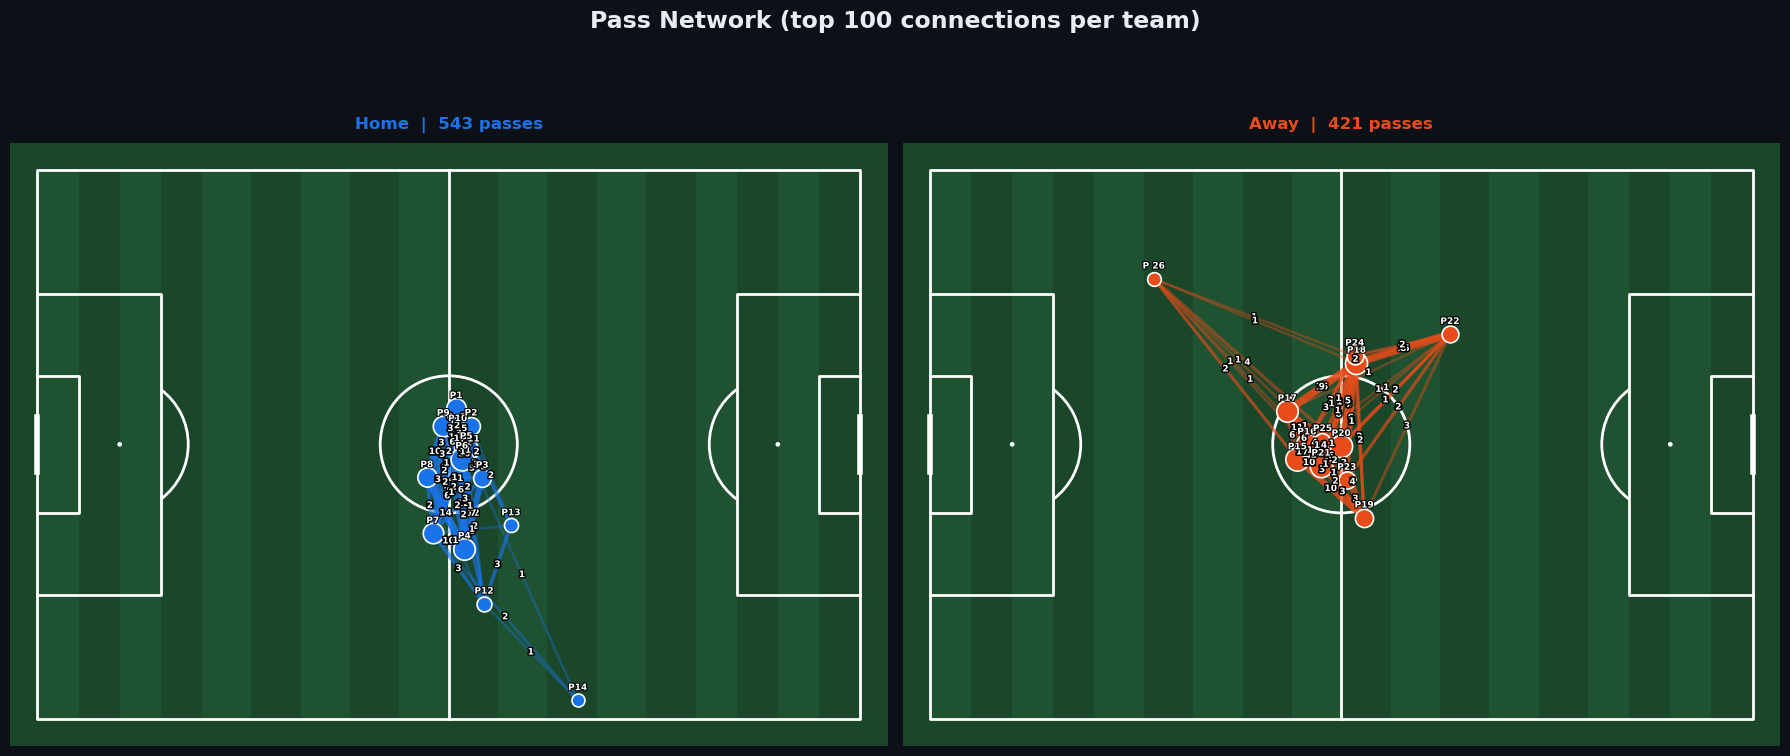

In [83]:
plot_pass_network(events,top_n=TOP_N,save_path="img/pass_network.png")

**HEATMAP**

In [84]:
from matplotlib.colors import LinearSegmentedColormap

HEAT_CMAP = LinearSegmentedColormap.from_list(
    "heat",
    ["#00000000", "#ff6b0055", "#ff6b00bb", "#ff0000ee"],
)


def plot_heatmap(df:pd.DataFrame,save_path:str=None)->None:

    TOUCH_TYPES = {"PASS","RECOVERY","SHOT","CHALLENGE"}
    touches = df[df["Type"].isin(TOUCH_TYPES)].dropna(
        subset=['Start X','Start Y']
    )

     # ── build mplsoccer pitch ─────────────────────────────────────────
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#1a472a",
        line_color="#ffffff",
        stripe=True,
        stripe_color="#1e5230",
        line_zorder=2,
    )
 
    fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(18, 8))
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(
        "Touch Heatmap", fontsize=17, fontweight="bold",
        color=TEXT_COLOR, y=1.02,
    )
 
    # ── one panel per team ────────────────────────────────────────────
    for team, color, ax in [
        ("Home", HOME_COLOR, axes[0]),
        ("Away", AWAY_COLOR, axes[1]),
    ]:
        t = touches[touches["Team"] == team]
 
        # scale coords to StatsBomb space
        xm, ym = _to_sb(t["Start X"].values, t["Start Y"].values)
 
        # bin_statistic() divides the pitch into bins_x × bins_y cells
        # and counts how many points fall in each — here 35 × 23 cells
        # gives roughly 3.4 m × 3.5 m per cell, fine enough for spatial detail
        stats = pitch.bin_statistic(
            xm, ym,
            statistic="count",   # sum the touch count per bin
            bins=(35, 23),       # (x_bins, y_bins)
            normalize=True,      # normalise to [0,1] so both teams are comparable
        )
 
        # heatmap() renders the binned data as a colour mesh on the pitch
        pitch.heatmap(
            stats, ax=ax,
            cmap=HEAT_CMAP,
            alpha=0.78,          # let pitch markings show through
            zorder=4,
        )
 
        ax.set_title(
            f"{team}  |  {len(t)} touches recorded",
            fontsize=12, fontweight="bold", color=color, pad=10,
        )
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()



Saved → img/heatmap.png


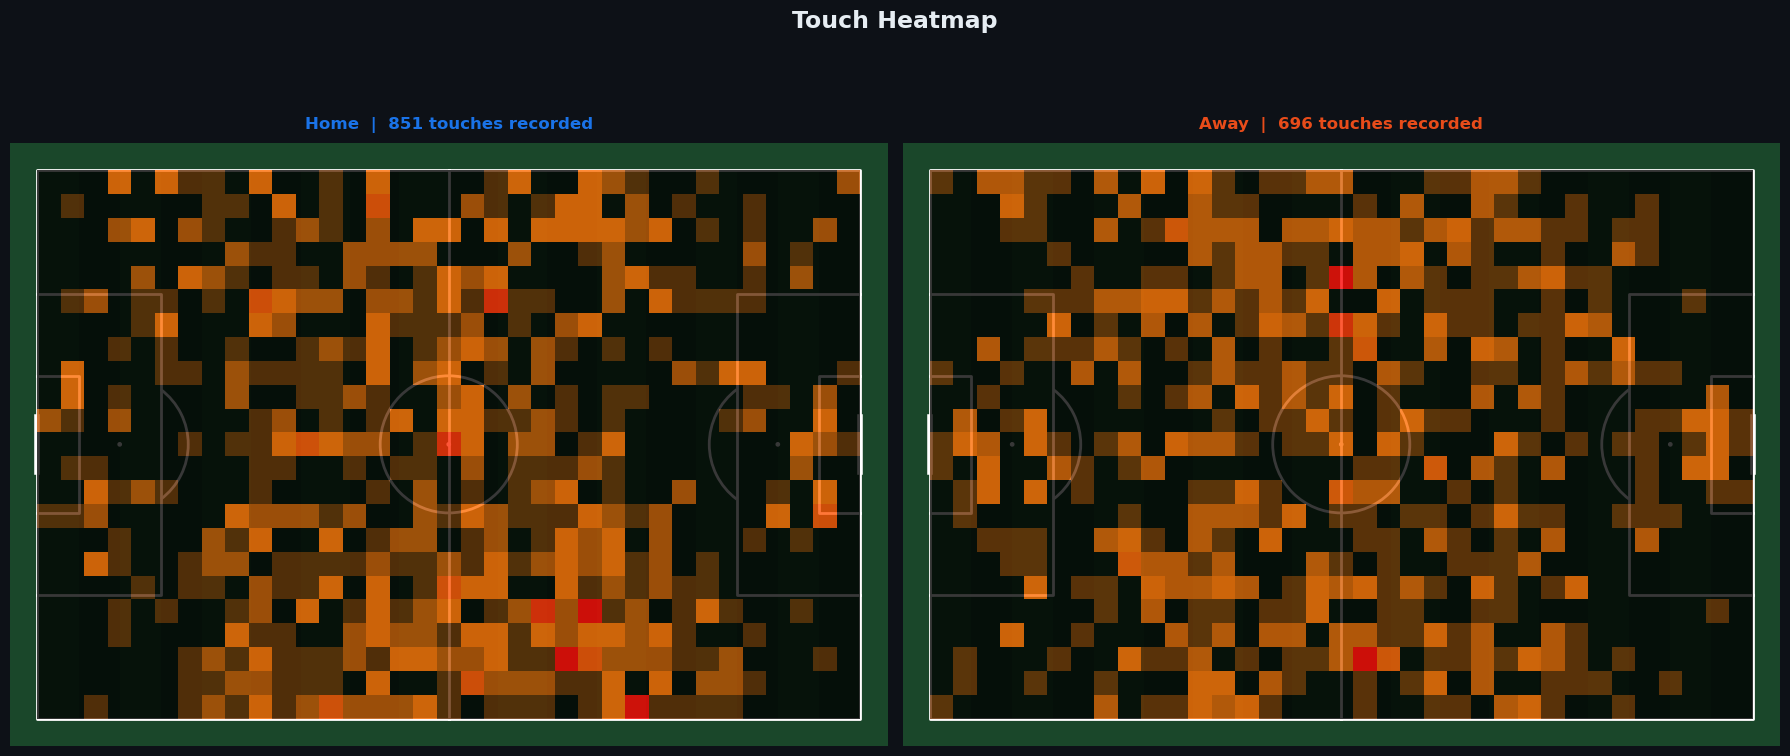

In [85]:
plot_heatmap(events,save_path='img/heatmap.png')

**DEFENSIVE ACTION MAP**

In [86]:
def plot_defensive_actions(df:pd.DataFrame,save_path:str=None)->None:
    tackles = df[
        (df['Type']=="CHALLENGE") &
        (df['Subtype'].str.contains('TACKLE'))
    ].dropna(subset=['Start X','Start Y'])

    interceptions = df[
        (df['Subtype']=="RECOVERY") &
        (df['Subtype'].str.contains('INTERCEPTION'))
    ].dropna(subset=['Start X','Start Y'])

    # ── build mplsoccer pitch ─────────────────────────────────────────
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#1a472a",
        line_color="#ffffff",
        stripe=True,
        stripe_color="#1e5230",
        line_zorder=2,
    )
 
    fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(18, 8))
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(
        "Defensive Actions  (Tackles & Interceptions)",
        fontsize=17, fontweight="bold", color=TEXT_COLOR, y=1.02,
    )
 
    # ── one panel per team ────────────────────────────────────────────
    for team, color, ax in [
        ("Home", HOME_COLOR, axes[0]),
        ("Away", AWAY_COLOR, axes[1]),
    ]:
        tt = tackles[tackles["Team"] == team]
        it = interceptions[interceptions["Team"] == team]
 
        # scale both datasets to StatsBomb coordinates
        txm, tym = _to_sb(tt["Start X"], tt["Start Y"])
        ixm, iym = _to_sb(it["Start X"], it["Start Y"])
 
        # ── tackles  (orange diamond ◆) ───────────────────────────────
        # pitch.scatter() is mplsoccer's spatial scatter — same API
        # as ax.scatter but understands the pitch coordinate system
        pitch.scatter(
            txm, tym, ax=ax,
            s=90, color="#FFA94D", edgecolors="white",
            linewidth=0.7, marker="D", alpha=0.85,
            zorder=5, label=f"Tackle ({len(tt)})",
        )
 
        # ── interceptions  (green triangle ▲) ────────────────────────
        pitch.scatter(
            ixm, iym, ax=ax,
            s=70, color="#6BFF9E", edgecolors="white",
            linewidth=0.7, marker="^", alpha=0.85,
            zorder=5, label=f"Interception ({len(it)})",
        )
 
        ax.legend(
            loc="upper right", framealpha=0.25, fontsize=9,
            labelcolor=TEXT_COLOR, facecolor=PANEL_COLOR, edgecolor=GRID_COLOR,
        )
        ax.set_title(
            f"{team}  |  Tackles: {len(tt)}   Interceptions: {len(it)}",
            fontsize=12, fontweight="bold", color=color, pad=10,
        )
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()

Saved → img/defensive_actions.png


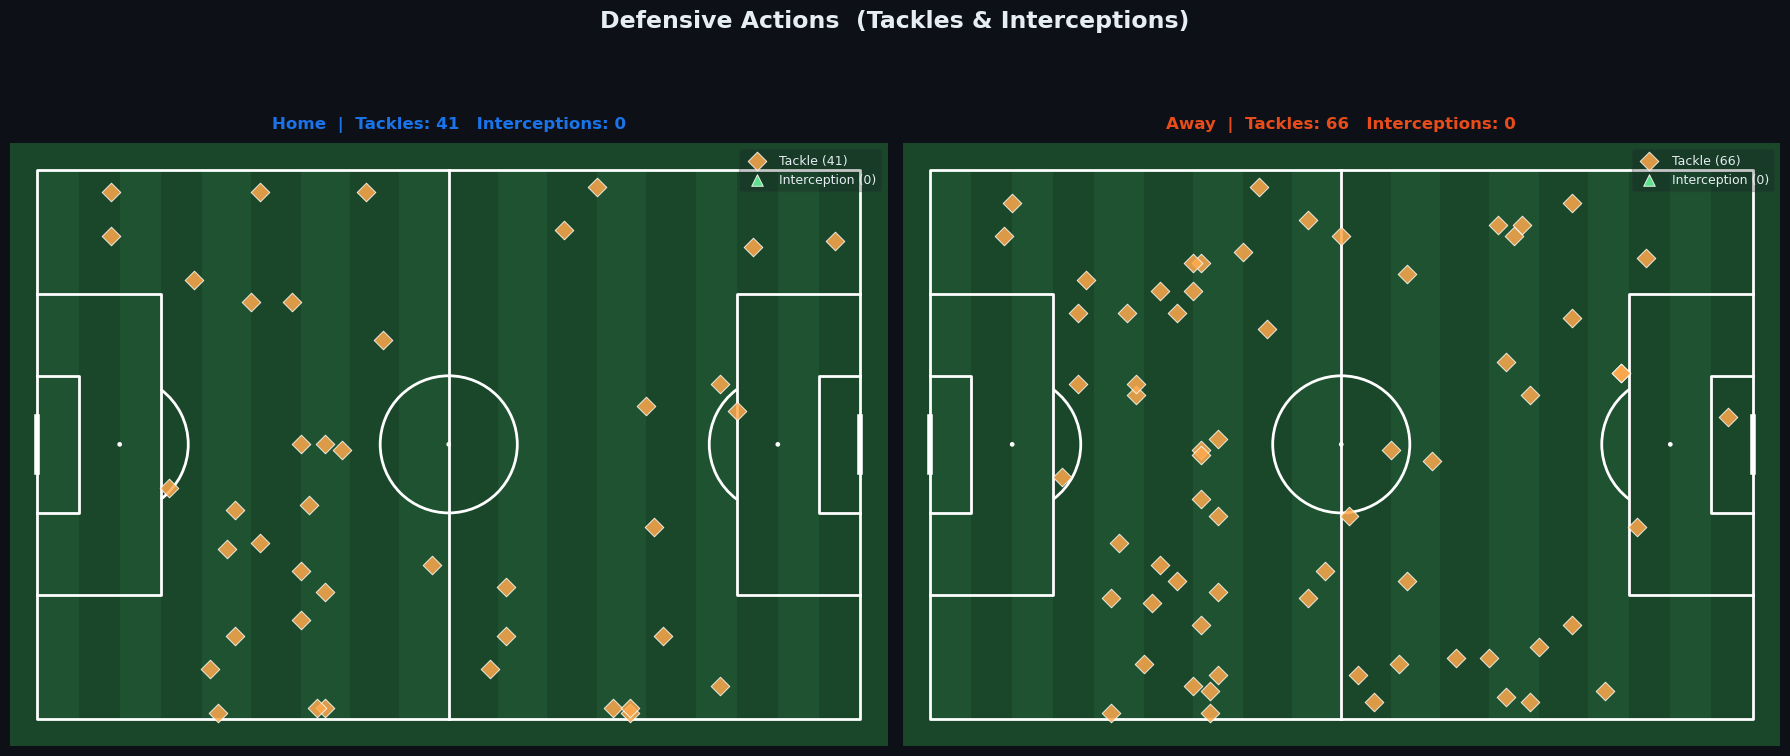

In [87]:
plot_defensive_actions(events,save_path='img/defensive_actions.png')

**Event Timeline**
Plots key match events as scatter points on a horizontal time axis.
mplsoccer is used only for the VerticalPitch mini-pitch thumbnails
drawn alongside the timeline to show where on the pitch each shot
occurred — the main timeline itself is a standard matplotlib axes.

- Gold -> shot
- Salmon -> Ball Lost
- Green -> Recovery
- Orange -> Challenge
- Purple -> Fault Received
- Red -> Card

In [88]:

import matplotlib.patches as mpatches
from mplsoccer import VerticalPitch

EVENT_MAP = {
    "SHOT":           ("*",  14, "gold"),
    "BALL LOST":      ("o",   7, "#FF6B6B"),
    "RECOVERY":       ("^",   7, "#6BFF9E"),
    "CHALLENGE":      ("D",   6, "#FFA94D"),
    "FAULT RECEIVED": ("P",   9, "#DA77F2"),
    "CARD":           ("s",  10, "#FF4444"),
}

def plot_event_timeline(df:pd.DataFrame,save_path:str=None)->None:
    
    fig = plt.figure(figsize=(18,9))
    fig.patch.set_facecolor(BG_COLOR)

    ax_main = fig.add_axes([0.05,0.35,0.90,0.55])
    ax_main.set_facecolor(PANEL_COLOR)


    # mini-pitch insets for Home (bottom-left) and Away (bottom-right)
    # VerticalPitch renders a vertical half-pitch (attacking end up)
    ax_home_pitch = fig.add_axes([0.05, 0.03, 0.40, 0.28])
    ax_away_pitch = fig.add_axes([0.55, 0.03, 0.40, 0.28])
 
    # ── main timeline ─────────────────────────────────────────────────
    ax_main.axhline( 1, color=HOME_COLOR, lw=1, alpha=0.3)   # Home lane
    ax_main.axhline(-1, color=AWAY_COLOR, lw=1, alpha=0.3)   # Away lane
    ax_main.axhline( 0, color=GRID_COLOR, lw=0.5)            # centre divider
 
    for _, row in df.iterrows():
        etype = row["Type"]
        if etype not in EVENT_MAP:
            continue   # skip types not in the legend
 
        marker, size, ec = EVENT_MAP[etype]
        y_val = 1 if row["Team"] == "Home" else -1
        ax_main.scatter(
            row["Start Time [s]"], y_val,
            marker=marker, s=size ** 2,
            color=ec, alpha=0.75, zorder=3,
        )
 
    # ── 2nd-half divider ──────────────────────────────────────────────
    p2_start = df[df["Period"] == 2]["Start Time [s]"].min()
    if not np.isnan(p2_start):
        ax_main.axvline(p2_start, color="white", lw=1.5,
                        linestyle="--", alpha=0.5)
        ax_main.text(p2_start + 10, 1.65,
                     "2nd Half", fontsize=9, color="white", alpha=0.6)
 
    # ── legend ────────────────────────────────────────────────────────
    type_patches = [
        mpatches.Patch(color=ec, label=name)
        for name, (_, _, ec) in EVENT_MAP.items()
    ]
    lane_patches = [
        mpatches.Patch(color=HOME_COLOR, label="Home (top)"),
        mpatches.Patch(color=AWAY_COLOR, label="Away (bottom)"),
    ]
    ax_main.legend(
        handles=type_patches + lane_patches,
        loc="lower right", framealpha=0.2,
        fontsize=8, ncol=4,
    )
 
    ax_main.set_xlabel("Time (seconds)", color=TEXT_COLOR)
    ax_main.set_title(
        "Event Timeline", fontsize=14, fontweight="bold", color=TEXT_COLOR,
    )
    ax_main.set_yticks([1, -1])
    ax_main.set_yticklabels(["Home", "Away"], color=TEXT_COLOR)
    ax_main.set_ylim(-2.2, 2.2)
    ax_main.grid(axis="x", alpha=0.2)
    ax_main.spines[["top", "right", "left", "bottom"]].set_visible(False)
 
    # ── mini mplsoccer pitch insets: shot locations ───────────────────
    # VerticalPitch with half=True shows only the attacking half
    # so shots are plotted in the context of where they were taken
    pitch = VerticalPitch(
        pitch_type="statsbomb",
        pitch_color="#1a472a",
        line_color="#ffffff",
        half=True,              # show only attacking half of the pitch
        line_zorder=2,
    )
 
    shots = df[df["Type"] == "SHOT"].dropna(subset=["Start X", "Start Y"])
    shots = shots.copy()
    shots["is_goal"] = shots["Subtype"].str.contains("GOAL")
 
    for team, color, ax_pitch, label in [
        ("Home", HOME_COLOR, ax_home_pitch, "Home — Shot Locations"),
        ("Away", AWAY_COLOR, ax_away_pitch, "Away — Shot Locations"),
    ]:
        pitch.draw(ax=ax_pitch)
        ax_pitch.set_facecolor("#1a472a")
 
        ts    = shots[shots["Team"] == team]
        goals = ts[ts["is_goal"]]
        other = ts[~ts["is_goal"]]
 
        # scale coords for VerticalPitch:
        # VerticalPitch flips x and y — x is the vertical axis (length),
        # y is the horizontal axis (width)
        oxm, oym = _to_sb(other["Start X"], other["Start Y"])
        gxm, gym = _to_sb(goals["Start X"], goals["Start Y"])
 
        pitch.scatter(oxm, oym, ax=ax_pitch,
                      s=60, color=color, edgecolors="white",
                      linewidth=0.6, alpha=0.75, zorder=4)
        pitch.scatter(gxm, gym, ax=ax_pitch,
                      s=150, color="gold", edgecolors="white",
                      linewidth=0.8, marker="*", alpha=1.0, zorder=5)
 
        ax_pitch.set_title(label, fontsize=9, fontweight="bold",
                           color=color, pad=6)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()


Saved → img/event_timeline.png


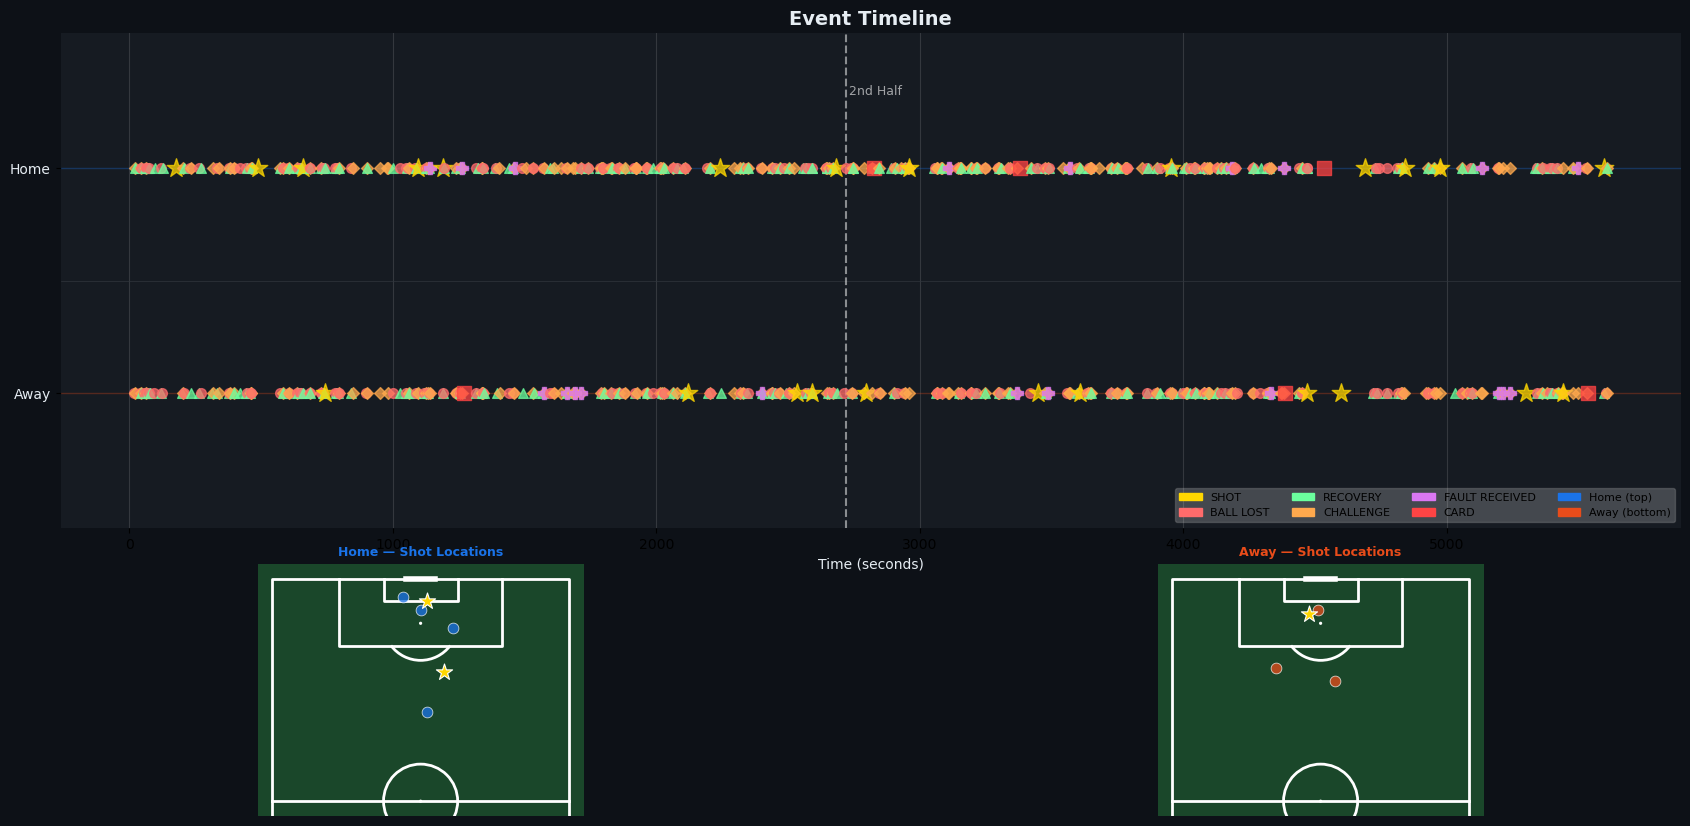

In [89]:
plot_event_timeline(events,save_path="img/event_timeline.png")

**Comparing Stats**


In [90]:
import matplotlib.patches as mpatches 

def _get(df, type_filter, subtype_filter=None):
    """Helper: filter by Type (and optionally Subtype), count per team."""
    mask = df["Type"] == type_filter
    if subtype_filter:
        mask &= df["Subtype"].str.contains(subtype_filter)
    return (df[mask].groupby("Team").size()
            .reindex(["Home", "Away"]).fillna(0).astype(int))

def compute_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a (metric × team) DataFrame with all 12 match stats."""
    passes = _get(df, "PASS")
    p_total = passes.sum()
 
    # pass accuracy: proxy = (passes − interception-losses) / passes
    lost = _get(df, "BALL LOST", "INTERCEPTION|HEAD")
    accuracy = ((passes - lost).clip(lower=0) / passes * 100).round(1)
 
    # fouls: FAULT RECEIVED is logged against the team fouled → flip index
    recv = _get(df, "FAULT RECEIVED")
    fouls = recv.rename(index={"Home": "Away", "Away": "Home"}).reindex(["Home", "Away"])
 
    stats = {
        "Goals":             _get(df, "SHOT", "GOAL"),
        "xG":                _get_total_xg(df),
        "Shots":             _get(df, "SHOT"),
        "Shots on Target":   _get(df, "SHOT", "ON TARGET"),
        "Passes":            passes,
        "Possession (%)":    (passes / p_total * 100).round(1),
        "Pass Accuracy (%)": accuracy,
        "Tackles":           _get(df, "CHALLENGE", "TACKLE"),
        "Fouls":             fouls,
        "Yellow Cards":      _get(df, "CARD", "YELLOW"),
        "Red Cards":         _get(df, "CARD", "RED"),
        "Interceptions":     _get(df, "RECOVERY", "INTERCEPTION"),
        "Corners":           _get(df, "SET PIECE", "CORNER KICK"),
    }
    s = pd.DataFrame(stats).T
    s.columns.name = "Team"
    return s
 

In [91]:
def plot_diverging_bar(df:pd.DataFrame,save_path:str=None)->None:
    #render head-to-head diverging bar chart
    summary = compute_summary(df)

    # ── ordered metric list (top → bottom visual order) ───────────────
    metrics = [
        ("Goals",             "Goals"),
        ("xG",                "xG (Expected Goals)"),
        ("Shots",             "Total Shots"),
        ("Shots on Target",   "Shots on Target"),
        ("Possession (%)",    "Possession (%)"),
        ("Passes",            "Passes"),
        ("Pass Accuracy (%)", "Pass Accuracy (%)"),
        ("Tackles",           "Tackles"),
        ("Fouls",             "Fouls"),
        ("Yellow Cards",      "Yellow Cards"),
        ("Red Cards",         "Red Cards"),
        ("Interceptions",     "Interceptions"),
        ("Corners",           "Corners"),
    ]
 
    labels    = [m[1] for m in metrics]
    home_vals = np.array([summary.loc[m[0], "Home"] for m in metrics], dtype=float)
    away_vals = np.array([summary.loc[m[0], "Away"] for m in metrics], dtype=float)
 
    # normalise: each side is a % of the higher value in that row
    max_vals  = np.where(np.maximum(home_vals, away_vals) == 0,
                         1, np.maximum(home_vals, away_vals))
    home_norm = home_vals / max_vals * 100
    away_norm = away_vals / max_vals * 100
 
    y = np.arange(len(labels))
 
    # ── figure setup ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)
 
    # ── mirrored bars: Home goes left (–x), Away goes right (+x) ─────
    ax.barh(y, -home_norm, height=0.55,
            color=HOME_COLOR, alpha=0.88, label="Home")
    ax.barh(y,  away_norm, height=0.55,
            color=AWAY_COLOR, alpha=0.88, label="Away")
 
    # ── raw value labels at bar tips ──────────────────────────────────
    for i, (hv, av, hn, an) in enumerate(
        zip(home_vals, away_vals, home_norm, away_norm)
    ):
        # show floats for percentage metrics, ints for counts
        fmt_h = f"{hv:.1f}" if isinstance(hv, float) and hv != int(hv) else f"{int(hv)}"
        fmt_a = f"{av:.1f}" if isinstance(av, float) and av != int(av) else f"{int(av)}"
        ax.text(-hn - 1.5, i, fmt_h,
                ha="right", va="center",
                fontsize=10, fontweight="bold", color=TEXT_COLOR)
        ax.text( an + 1.5, i, fmt_a,
                ha="left",  va="center",
                fontsize=10, fontweight="bold", color=TEXT_COLOR)
 
    # ── metric labels centred on the zero axis ────────────────────────
    for i, lbl in enumerate(labels):
        ax.text(
            0, i, lbl,
            ha="center", va="center",
            fontsize=9.5, fontweight="bold", color=TEXT_COLOR,
            bbox=dict(boxstyle="round,pad=0.25",
                      facecolor=PANEL_COLOR,
                      edgecolor=GRID_COLOR,
                      alpha=0.9),
        )
 
    # ── scoreline badge at the top ────────────────────────────────────
    hg = int(summary.loc["Goals", "Home"])
    ag = int(summary.loc["Goals", "Away"])
    n  = len(labels)
 
    ax.text(-50, n + 0.35, f"HOME  {hg}",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold", color=HOME_COLOR)
    ax.text(  0, n + 0.35, "vs",
            ha="center", va="bottom",
            fontsize=14, color=TEXT_COLOR)
    ax.text( 50, n + 0.35, f"{ag}  AWAY",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold", color=AWAY_COLOR)
 
    # ── axis & spine styling ──────────────────────────────────────────
    ax.set_xlim(-130, 130)
    ax.set_ylim(-0.8, n + 0.9)
    ax.set_yticks([]);  ax.set_xticks([])
    ax.axvline(0, color=GRID_COLOR, lw=1.2)   # centre divider
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title(
        "Match Statistics — Head to Head",
        fontsize=17, fontweight="bold", color=TEXT_COLOR, pad=20,
    )
    ax.legend(
        handles=[
            mpatches.Patch(color=HOME_COLOR, label="Home"),
            mpatches.Patch(color=AWAY_COLOR, label="Away"),
        ],
        loc="lower center", ncol=2,
        framealpha=0.2, fontsize=11,
    )
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=BG_COLOR)
        print(f"Saved → {save_path}")
    plt.show()


Saved → img/diverging_bar.png


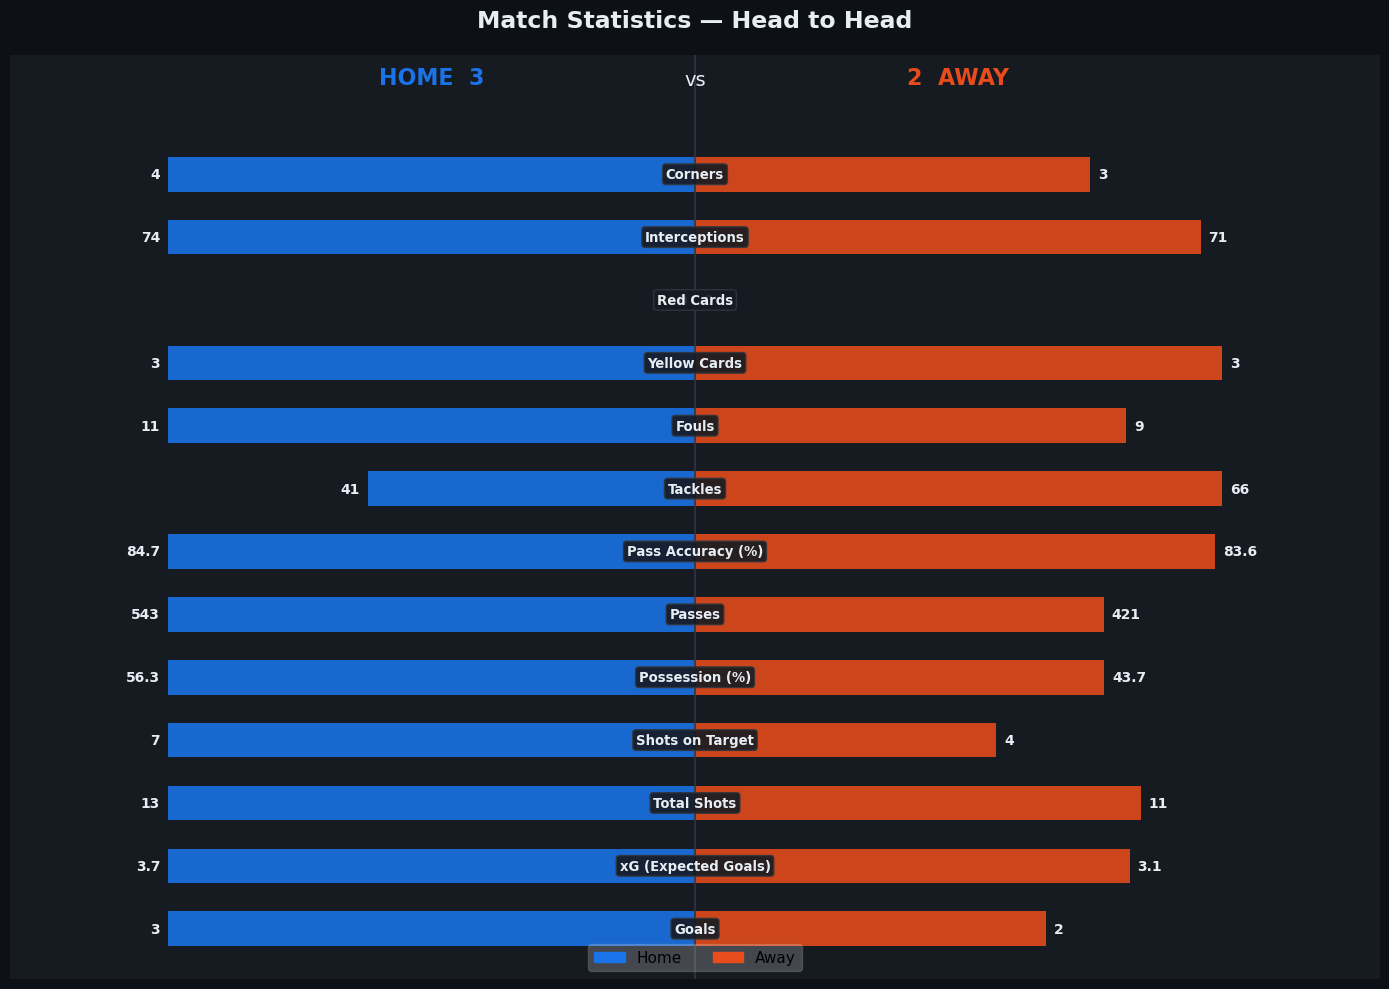

In [92]:
plot_diverging_bar(events,save_path='img/diverging_bar.png')

## Pressing Analysis

In [95]:
!pip install mplsoccer

In [93]:
from mlpsoccer import Pitch


ModuleNotFoundError: No module named 'mlpsoccer'